# Machine learning

---

## ATom data

- This notebook makes use of measurements from deployment 1 of NASA's Atmospheric Tomography Mission (ATom), which was carried out in June-August 2016 and consisted of regular 0.2–12 km profiling. (https://doi.org/10.5194/essd-15-3299-2023)
- In this notebook we will look at a dataset containing mixing ratios of hydrogen oxides measured by the Airborne Tropospheric Hydrogen Oxides Sensor (ATHOS) from this deployment, and use it to build up an atmospheric 0-dimensional, 1-box model of OH concentrations. (https://doi.org/10.3334/ORNLDAAC/1877)
- https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf

---

## Inspect dataset

In [1]:
import pandas as pd
df = pd.read_csv("MDS_atom1_2016_summer_with_no_no2_oh_ho2_full_js.csv")

In [2]:
df.shape

(6550, 144)

In [3]:
len(df)

6550

Filtering out the dataset to only keep the columns of interest:

In [4]:
df = df[['Temp', 'Pres','UTC_Start_dt', 'lat', 'lon', 'Altitude', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'OH_ATHOS', 'CO_M', 'CH4_M', 'PAN_M', 'HO2_ATHOS']]
# df

In [5]:
from datetime import datetime, timezone
import numpy as np
from pytz import timezone
df["UTC_Start_dt"] = pd.to_datetime(df["UTC_Start_dt"])
df['UTC_Start_dt'] = df['UTC_Start_dt'].dt.tz_localize('UTC')
df["UTC_Start_dt"] = df["UTC_Start_dt"].dt.tz_convert('America/New_York')
df['date'] = df['UTC_Start_dt']
# df['date']

In [6]:
## Unit conversions
from datetime import datetime, timezone
import numpy as np
from pytz import timezone

kb = 1.38e-23 # J K^−1 Boltzmann's constant

for i in range(len(df)):
    # Convert the dates to a timestamp value so that the difference between times can be calculated as an integer
    df.loc[i, "t"] = df["UTC_Start_dt"][i].replace().timestamp() - df["UTC_Start_dt"][0].replace().timestamp()
    df.loc[i, "M"] = ((df.loc[i, "Pres"] * 100) / (kb * df.loc[i, "Temp"])) * 1e-6 ## molecules cm^3 pressure was in hPa

# df.head()


In [7]:
df['kH2O'] = 1.63e-10 * np.exp(--60/df["Temp"]) ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kM'] = 2.15e-11 * np.exp(--110/df["Temp"]) ## ## page 21 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf


df["O3"] = df["O3_M"] * df["M"]
df["H2O"] = df["H2O_M"] *  df["M"]
df["[OH]_measured"] = df["OH_ATHOS"] * 1e-12 * df["M"] # in ppt


In [8]:
for i in range(len(df)):
    df.loc[i, "O1D"] = (df["jO3_O2_O1D_CAFS"][i] * df["O3_M"][i]) / ((df['kH2O'][i] * df["H2O_M"][i]) + (df['kM'][i]))
    df.loc[i, "source"] = 2 * df['kH2O'][i] * df["O1D"][i] * df["H2O"][i]
print(df["O1D"].mean())
print(df["source"].mean())
# df.head()

# source should be 10e5

0.05354202636146678
714621.1551027566


In [9]:
df["source"].mean()

np.float64(714621.1551027566)

In [10]:
df["P_atm"] = 0.000987 * df["Pres"]
# df['kCO'] = 1.85e-13 * np.exp(-(65/df['Temp'])) * 24/15 ## page 484 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df['kCO']  = 1.5e-13  * (1.0 + 0.6 * df["P_atm"]) #where P is the pressure in atmospheres
df['kCH4'] = 2.45e-12 * np.exp(-1775/df['Temp']) ## page 106 of https://jpldataeval.jpl.nasa.gov/pdf/NASA-JPL%20Evaluation%2019-5.pdf
df["CO"] = df['CO_M'] * df["M"]
df["CH4"] = df['CH4_M'] * df["M"]

for i in range(len(df)):
    df.loc[i, "[OH]_calc"] = (df.loc[i, "source"])/ ((df['kCO'][i] * df["CO"][i]) + (df['kCH4'][i] * df["CH4"][i]))
df["[OH]_calc"]

0       2.612957e+05
1       1.811806e+05
2       9.325155e+04
3       1.084854e+05
4       1.370618e+05
            ...     
6545    5.493687e+06
6546    5.625367e+06
6547    5.694019e+06
6548    5.569411e+06
6549    6.971896e+06
Name: [OH]_calc, Length: 6550, dtype: float64

In [13]:
from sklearn.metrics import r2_score

## Machine learning

<Axes: >

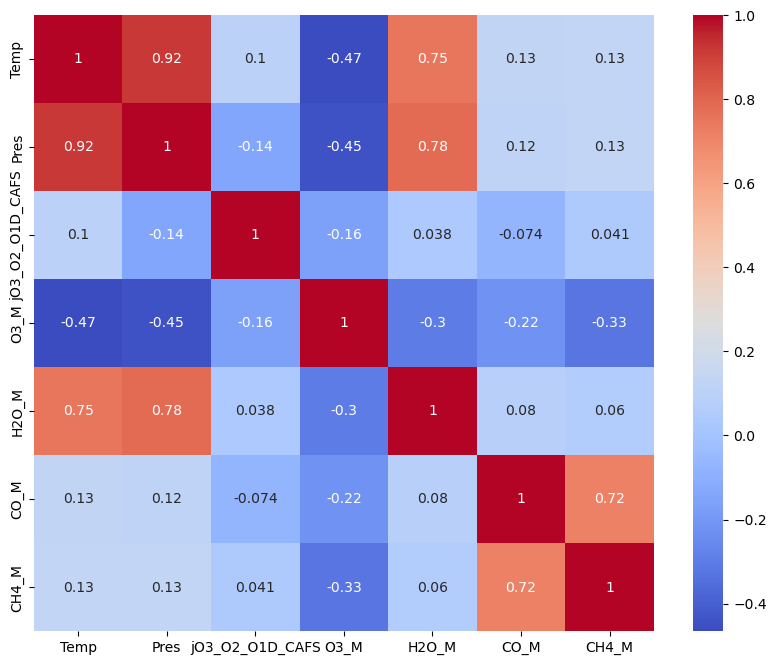

In [18]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(10,8))
df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
matrix = df_inputs.corr(numeric_only=True)
sns.heatmap(matrix, cmap="coolwarm", annot=True)

### Linear regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

LinearRegression fits a linear model with coefficients w = (w1, …, wp) to minimize the residual sum of squares between the observed targets in the dataset, and the targets predicted by the linear approximation.

Model score on training data: 0.4795417963760251
Model score on testing data: 0.48477641826064555
WITH HO2
Model score on training data: 0.5751355505710259
Model score on testing data: 0.5640057970059092


<Axes: ylabel='altitude / m'>

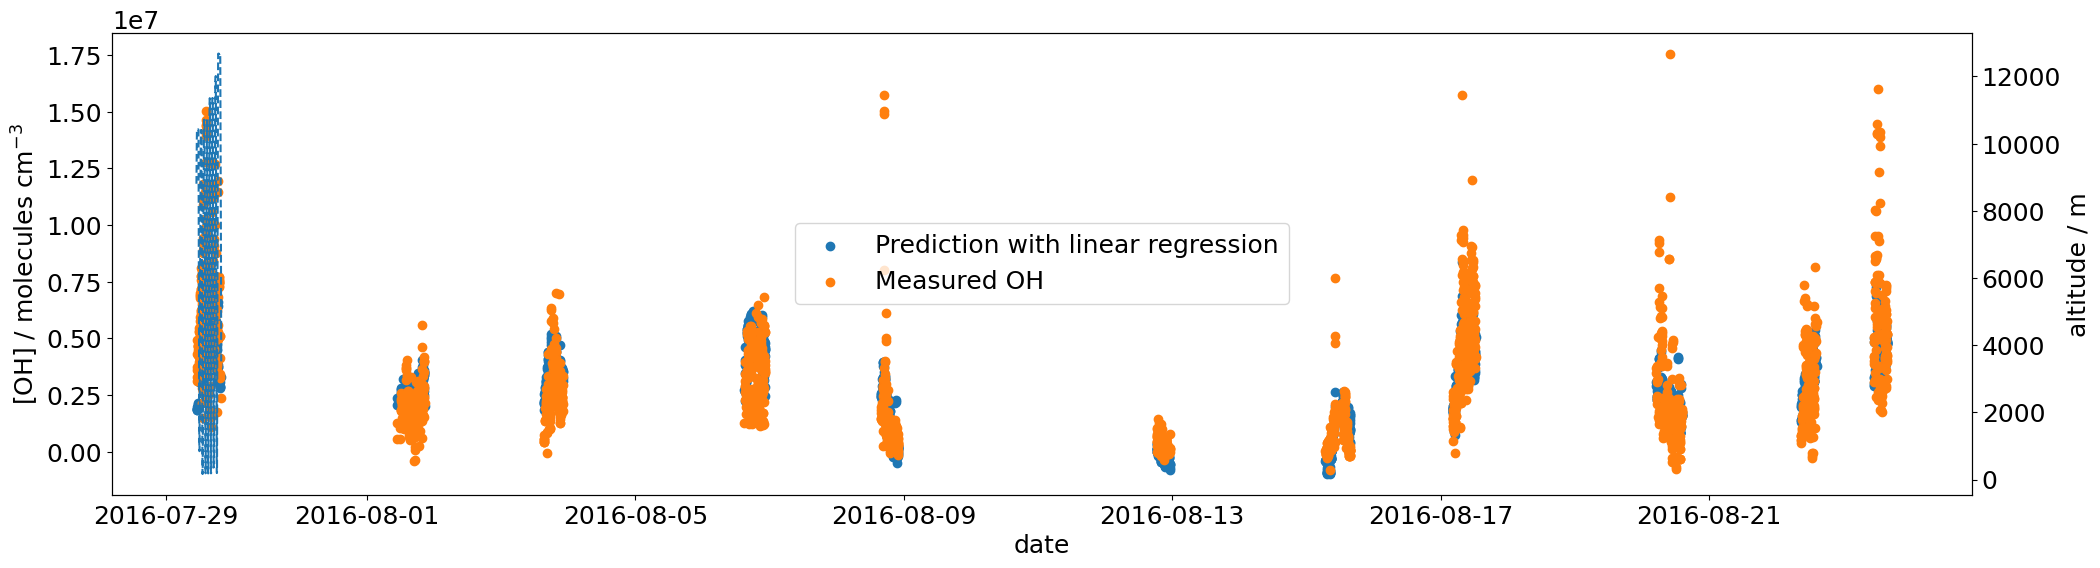

In [41]:
from sklearn.linear_model import LinearRegression

# X = df_inputs
# y = df["[OH]_measured"]

# # Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.4, random_state=42
# )
import matplotlib as mpl
reg = LinearRegression().fit(X_train, y_train)
pred_reg = reg.predict(X_test)

reg_HO2 = LinearRegression().fit(X_train_HO2, y_train)
pred_reg_HO2 = reg_HO2.predict(X_test_HO2)

print(f"Model score on training data: {reg.score(X_train, y_train)}")
print(f"Model score on testing data: {reg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {reg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {reg_HO2.score(X_test_HO2, y_test)}")


mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], pred_reg, label = "Prediction with linear regression")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
# ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2



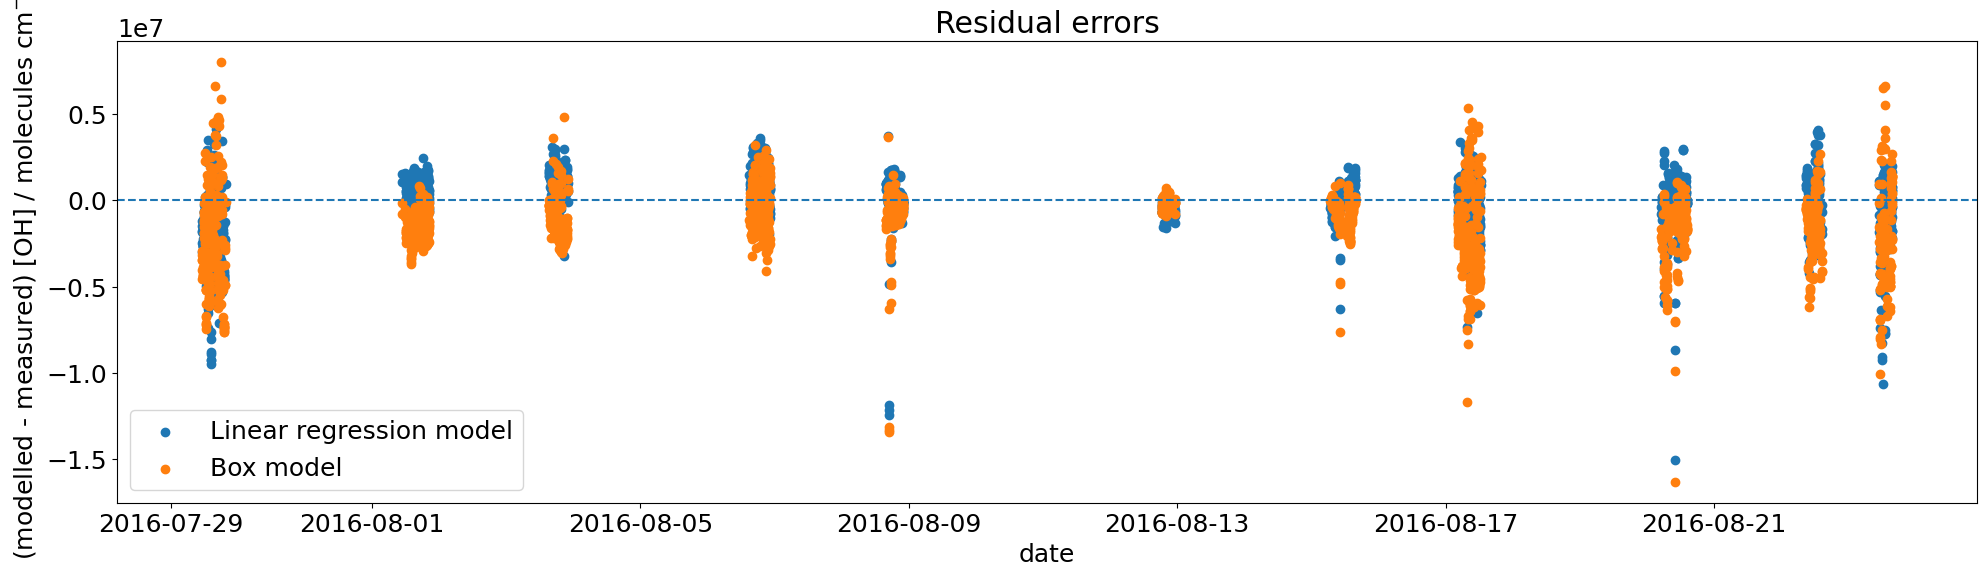

RMSE: 1920286.1265571208


In [28]:
mpl.rcParams["font.size"] = 18

# y_test = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][X_test.index], (reg.predict(X_test) - y_test), label='Linear regression model')


plt.scatter(df["date"][X_test.index], (df["[OH]_calc"][X_test.index] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_reg)))
# print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_reg_HO2)))

### Random forest
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

A random forest is a meta estimator that fits a number of decision tree classifiers on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

Model score on training data: 0.9748230713879255
Model score on testing data: 0.8379555468268797
WITH HO2
Model score on training data: 0.9739249832482755
Model score on testing data: 0.8265409090361445


<Axes: ylabel='altitude / m'>

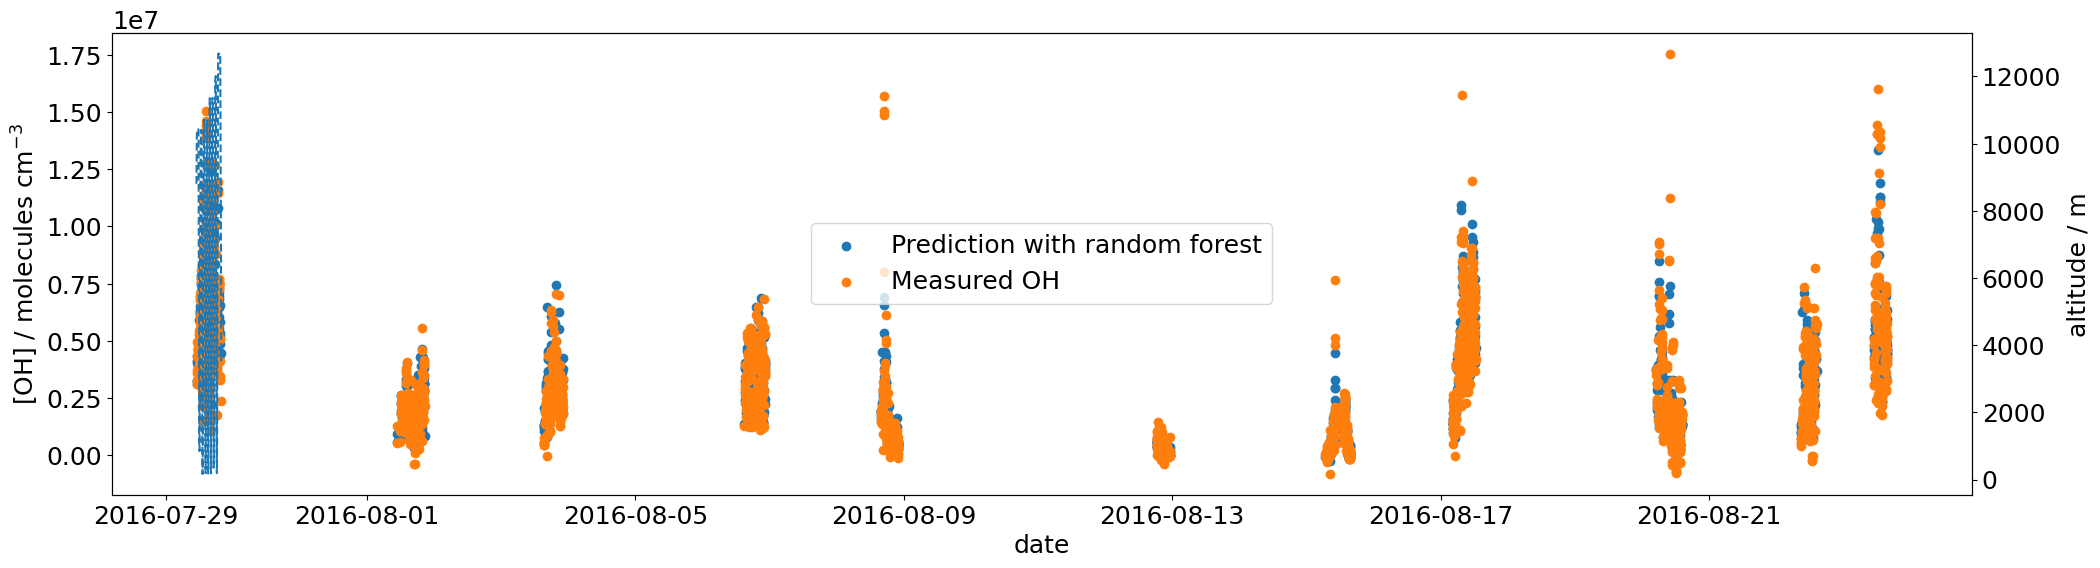

In [42]:
from sklearn.ensemble import RandomForestRegressor
rfreg = RandomForestRegressor()

rfreg.fit(X_train, y_train)

pred_rfreg = rfreg.predict(X_test)


rfreg_HO2 = RandomForestRegressor()

rfreg_HO2.fit(X_train_HO2, y_train)

pred_rfreg_HO2 = rfreg_HO2.predict(X_test_HO2)





print(f"Model score on training data: {rfreg.score(X_train, y_train)}")
print(f"Model score on testing data: {rfreg.score(X_test, y_test)}")

print("WITH HO2")

print(f"Model score on training data: {rfreg_HO2.score(X_train_HO2, y_train)}")
print(f"Model score on testing data: {rfreg_HO2.score(X_test_HO2, y_test)}")

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], pred_rfreg, label = "Prediction with random forest")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
# ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

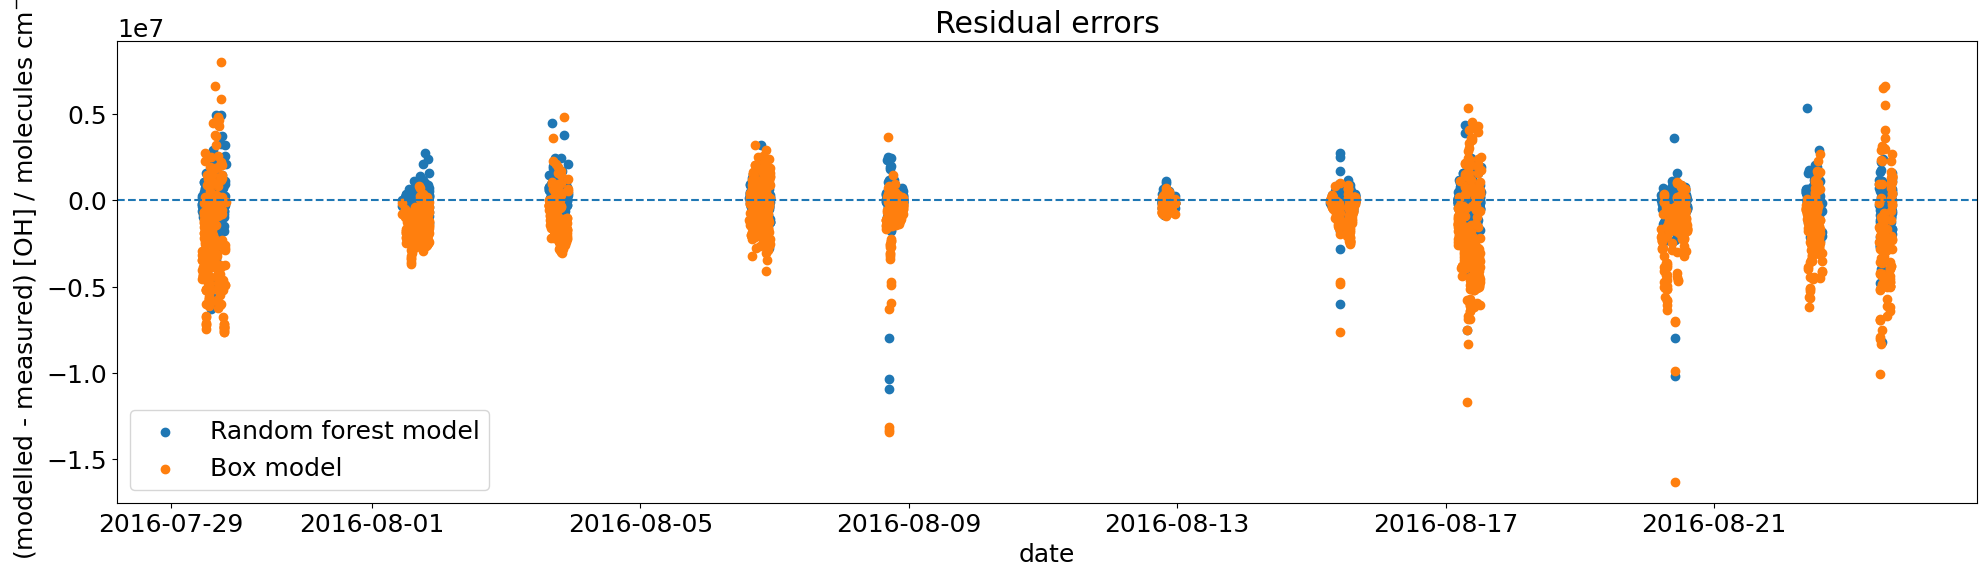

RMSE: 1076924.265957105
RMSE with HO2: 1114208.8690906467


In [46]:
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][X_test.index], (rfreg.predict(X_test) - y_test),label='Random forest model')
plt.scatter(df["date"][X_test.index], (df["[OH]_calc"][X_test.index] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rfreg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_rfreg_HO2)))

### Feature importance with random forest

Text(0, 0.5, 'Feature')

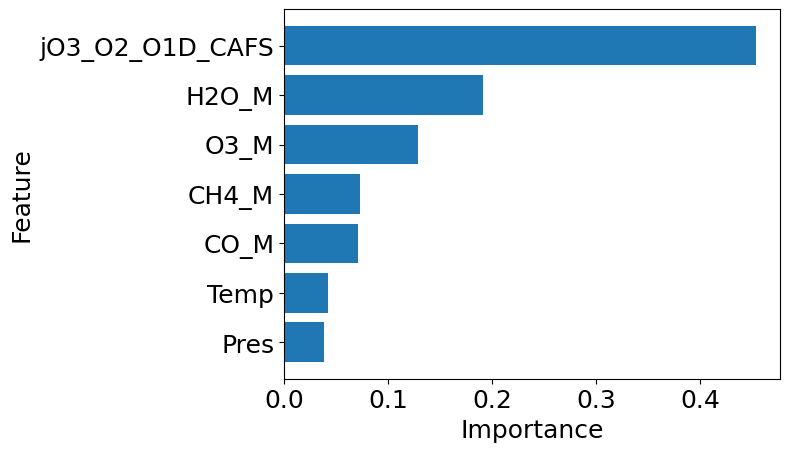

In [31]:
importances = rfreg.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")

Results are as expected - the production of OH depends strongly on the reaction between O(1D) and H2O and this process requires UV from sunlight.

### Ridge regression
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

Ridge regression is an example of a regularisation procedure, which is an extension of the linear model.

This model solves a regression model where the loss function is the linear least squares function and regularization is given by the l2-norm

Used when there is collinearity in input values and ordinary least squares would overfit training data.

Model score on training data: 0.479541291132782
Model score on testing data: 0.48407174298407285
WITH HO2
Model score on training data: 0.5751354947970899
Model score on testing data: 0.5622016437511324


<Axes: ylabel='altitude / m'>

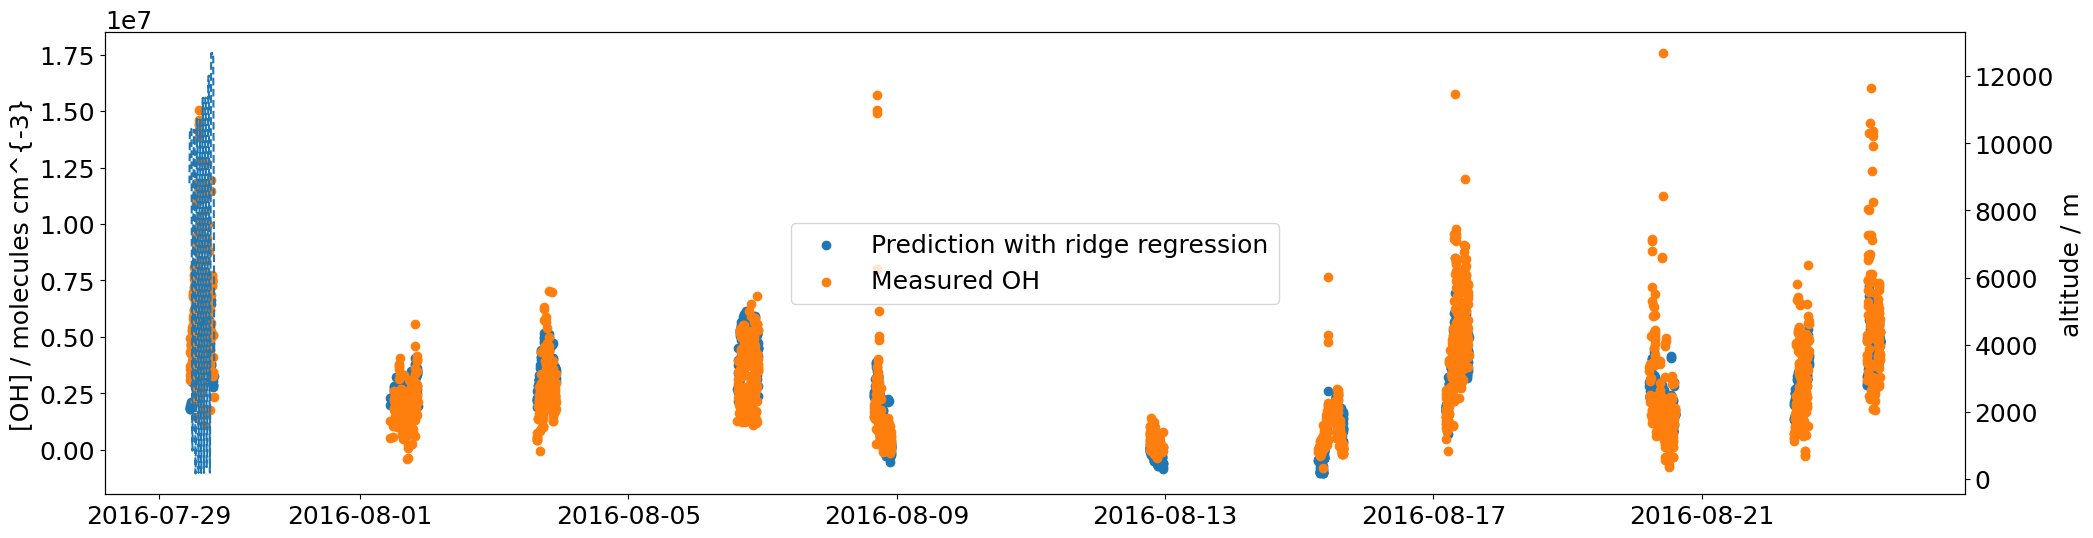

In [44]:
import sklearn
from sklearn.linear_model import Ridge

X = df_inputs   # 100 samples, 5 input features
y = df["[OH]_measured"]  # single output


# X_train = df_inputs[df["date"] > "2016-07-30"]
X_train_normalised = scaler.fit_transform(X_train)
# y_train = df[["[OH]_measured"]][df["date"] > "2016-07-30"]
# y_train_normalised = scaler.fit_transform(y_train)

# X_test = df_inputs[(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
X_test_normalised = scaler.fit_transform(X_test)
# y_test = df[["[OH]_measured"]][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")]
# y_test_normalised = scaler.transform(y_test)

ridgereg = Ridge(alpha=1)  # alpha controls the regularization strength
ridgereg.fit(X_train_normalised, y_train)

pred_ridgereg = ridgereg.predict(X_test_normalised)

ridgereg_HO2 = Ridge(alpha=1)  # alpha controls the regularization strength
ridgereg_HO2.fit(X_train_normalised_HO2, y_train)

pred_ridgereg_HO2 = ridgereg_HO2.predict(X_test_normalised_HO2)


print("Model score on training data:", ridgereg.score(X_train_normalised, y_train))
print("Model score on testing data:", ridgereg.score(X_test_normalised, y_test))

print("WITH HO2")

print("Model score on training data:", ridgereg_HO2.score(X_train_normalised_HO2, y_train))
print("Model score on testing data:", ridgereg_HO2.score(X_test_normalised_HO2, y_test))

fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_ylabel('[OH] / molecules cm^{-3}')
ax1.scatter(df["date"][X_test.index], pred_ridgereg, label = "Prediction with ridge regression")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
# ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2

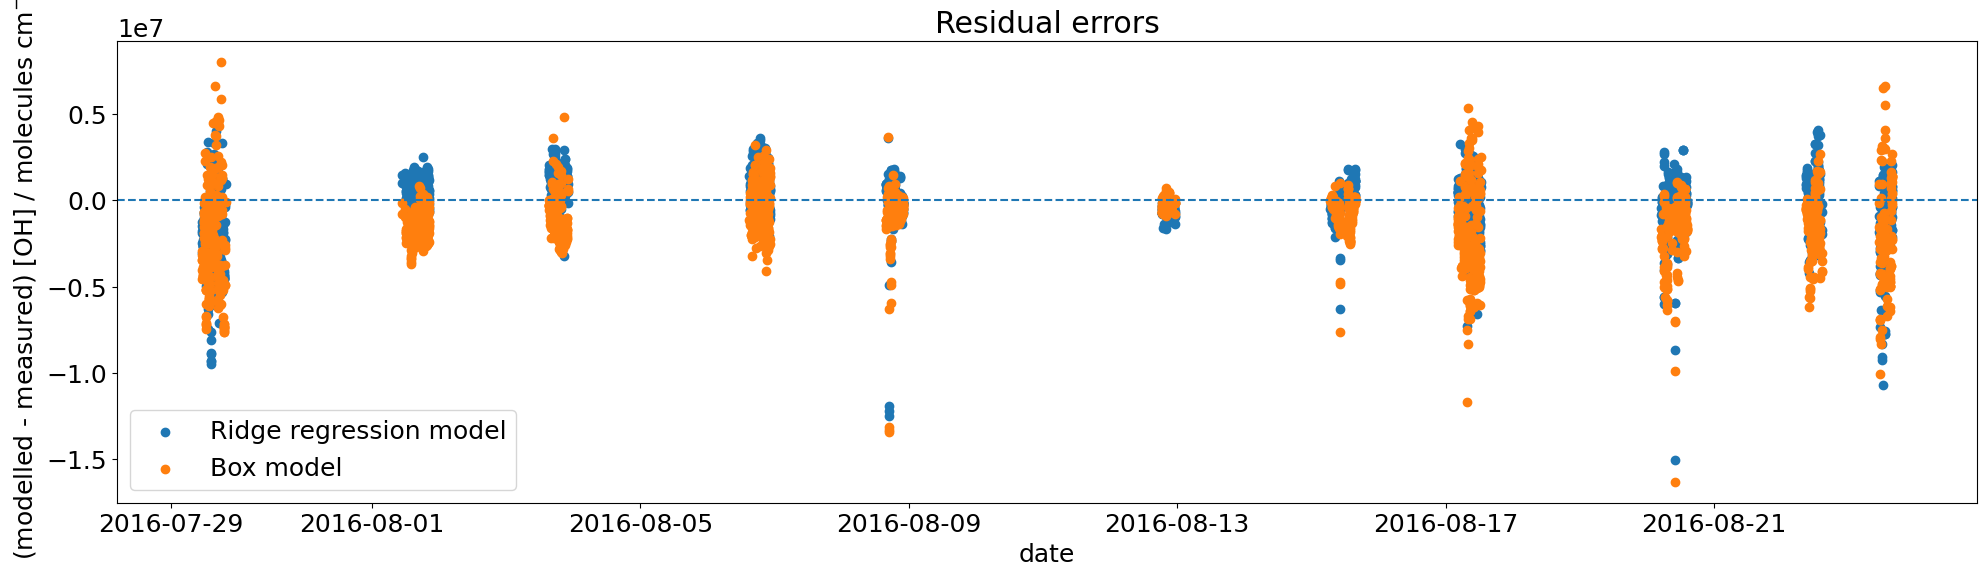

RMSE: 1921598.8729388444
RMSE with HO2: 1770129.9138798097


In [45]:
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][X_test.index], (ridgereg.predict(X_test_normalised) - y_test),label='Ridge regression model')
plt.scatter(df["date"][X_test.index], (df["[OH]_calc"][X_test.index] - y_test),label='Box model')


# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")


# method call for showing the plot
plt.show()
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridgereg)))
print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, pred_ridgereg_HO2)))

### Gradient boosting
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

This algorithm builds an additive model in a forward stage-wise fashion. It produces a predictive model from an ensemble of weak predictive models

In [20]:
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [21]:
df

,Temp,Pres,UTC_Start_dt,lat,lon,Altitude,jO3_O2_O1D_CAFS,O3_M,H2O_M,OH_ATHOS,...,[OH]_measured,O1D,source,P_atm,kCO,kCH4,CO,CH4,[OH]_calc,ratio
0,249.265,343.334,2016-07-29 10:56:10-04:00,33.01171,241.10200,8804.58,0.000009,8.640570e-08,0.000447,0.300,...,2.994316e+06,0.023588,4.362068e+04,0.338871,1.804984e-13,1.979626e-15,7.220262e+11,1.849609e+13,2.612957e+05,0.087264
1,248.771,337.478,2016-07-29 10:56:40-04:00,32.96985,241.04760,8931.10,0.000009,7.601130e-08,0.000332,0.300,...,2.949089e+06,0.021093,2.855602e+04,0.333091,1.799782e-13,1.951830e-15,6.783544e+11,1.819925e+13,1.811806e+05,0.061436
2,248.851,331.741,2016-07-29 10:57:10-04:00,32.92798,240.99323,9057.14,0.000009,8.291030e-08,0.000158,0.300,...,2.898024e+06,0.023270,1.475520e+04,0.327428,1.794686e-13,1.956312e-15,6.867118e+11,1.788412e+13,9.325155e+04,0.032178
3,246.160,315.391,2016-07-29 10:58:40-04:00,32.80281,240.83030,9425.14,0.000010,8.132570e-08,0.000169,0.276,...,2.562488e+06,0.023840,1.557405e+04,0.311291,1.780162e-13,1.809564e-15,6.317127e+11,1.718857e+13,1.084854e+05,0.042336
4,245.201,309.998,2016-07-29 10:59:10-04:00,32.76114,240.77659,9550.39,0.000010,8.148520e-08,0.000207,0.276,...,2.528521e+06,0.024238,1.913352e+04,0.305968,1.775371e-13,1.759244e-15,6.182354e+11,1.696073e+13,1.370618e+05,0.054206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6545,287.376,734.283,2016-08-23 15:51:00-04:00,34.94797,242.36580,2818.77,0.000048,5.419620e-08,0.007266,0.227,...,4.203003e+06,0.078281,4.230655e+06,0.724737,2.152264e-13,5.089941e-15,2.751005e+12,3.497195e+13,5.493687e+06,1.307086
6546,288.683,749.875,2016-08-23 15:51:30-04:00,34.91515,242.35962,2641.88,0.000047,5.082710e-08,0.007460,0.227,...,4.272818e+06,0.072279,4.073197e+06,0.740127,2.166114e-13,5.234286e-15,2.485033e+12,3.549489e+13,5.625367e+06,1.316547
6547,290.545,771.085,2016-08-23 15:52:00-04:00,34.88332,242.34174,2403.69,0.000046,5.125980e-08,0.007838,0.240,...,4.615524e+06,0.071118,4.296305e+06,0.761061,2.184955e-13,5.444657e-15,2.548761e+12,3.629920e+13,5.694019e+06,1.233667
6548,291.259,777.013,2016-08-23 15:52:30-04:00,34.85163,242.32323,2339.75,0.000046,5.167830e-08,0.007777,0.240,...,4.639606e+06,0.071725,4.319411e+06,0.766912,2.190221e-13,5.526811e-15,2.620191e+12,3.649122e+13,5.569411e+06,1.200406


In [22]:
df_inputs = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M']]
df_inputs_HO2 = df[['Temp', 'Pres', 'jO3_O2_O1D_CAFS', 'O3_M', 'H2O_M', 'CO_M', 'CH4_M', 'HO2_ATHOS']]

Model score on training data: 0.802711303131296
Model score on testing data: 0.7330754544763082
WITH HO2 AS TRAINING DATA
Model score on training data: 0.8146697492150764
Model score on testing data: 0.7340877253649073


<Axes: ylabel='altitude / m'>

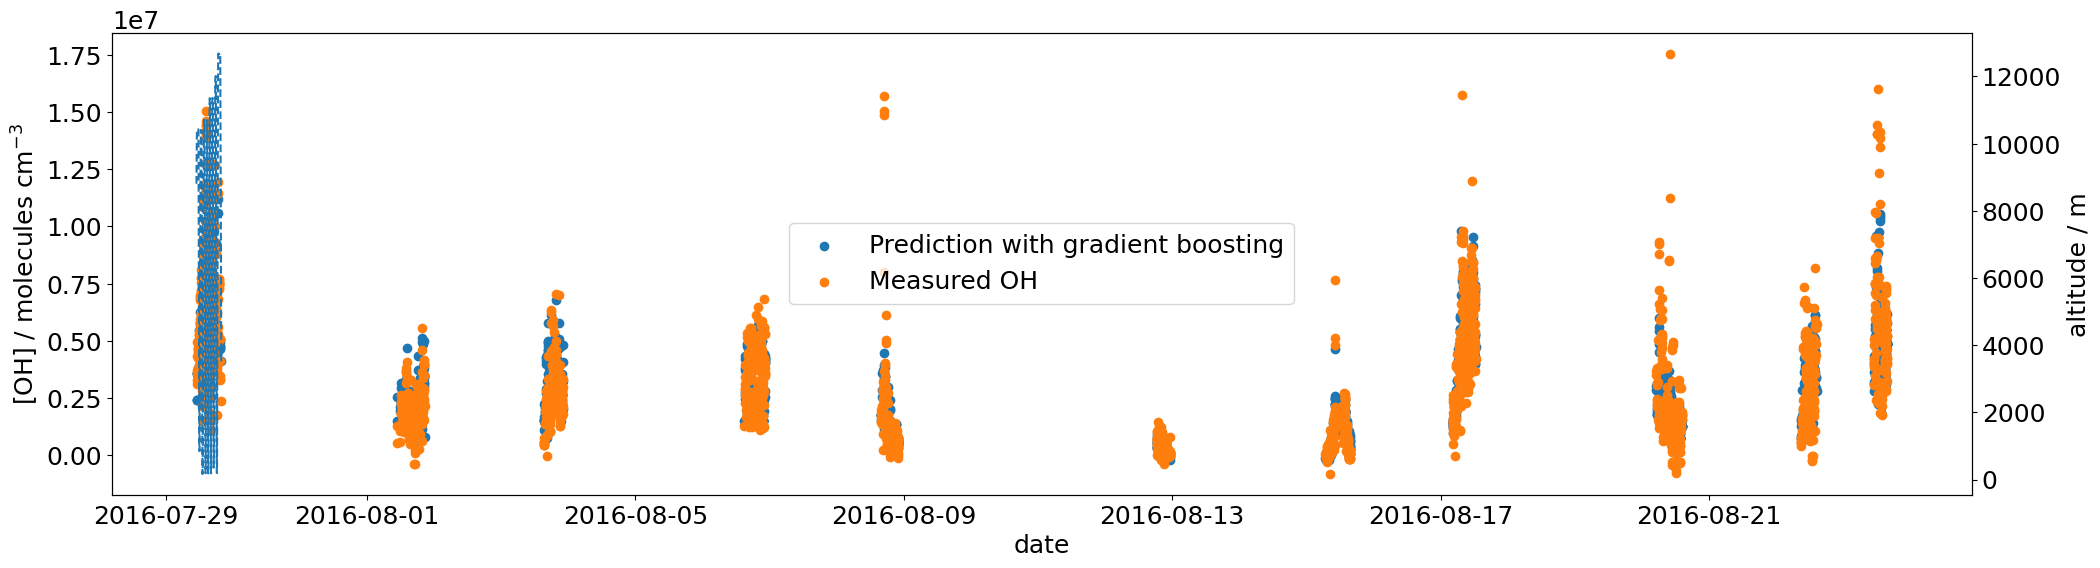

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Example data
X = df_inputs   # 100 samples, 5 input features
X_HO2 = df_inputs_HO2
y = df["[OH]_measured"]  # single output

# using the train test split function
X_train, X_test, y_train, y_test = train_test_split(X,y,
                                   random_state=42, 
                                   test_size=0.3, 
                                   shuffle=True)

X_train_HO2, X_test_HO2, y_train_HO2, y_test_HO2 = train_test_split(X_HO2,y,
                                   random_state=42, 
                                   test_size=0.3, 
                                   shuffle=True)

X_train_normalised = scaler.fit_transform(X_train)

# X_train_HO2 = df_inputs_HO2[df["date"] > "2016-07-30"]
X_train_normalised_HO2 = scaler.fit_transform(X_train_HO2)

X_test_normalised = scaler.fit_transform(X_test)

X_test_normalised_HO2 = scaler.fit_transform(X_test_HO2)

# Normalise

# GBRT model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

model_HO2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05
)

# Train
model.fit(X_train_normalised, y_train)

model_HO2.fit(X_train_normalised_HO2, y_train)

y_pred = model.predict(X_test_normalised)

y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)

# Predict
# y_pred_HO2 = model_HO2.predict(X_test_normalised_HO2)



print(f"Model score on training data: {model.score(X_train_normalised, y_train)}")
print(f"Model score on testing data: {model.score(X_test_normalised, y_test)}")

print("WITH HO2 AS TRAINING DATA")

print(f"Model score on training data: {model_HO2.score(X_train_normalised_HO2, y_train)}")
print(f"Model score on testing data: {model_HO2.score(X_test_normalised_HO2, y_test)}")

import matplotlib as mpl
mpl.rcParams["font.size"] = 18


fig, ax1 = plt.subplots(figsize = (24, 6))
ax1.set_xlabel('date')
ax1.set_ylabel('[OH] / molecules cm$^{-3}$')
ax1.scatter(df["date"][X_test.index], y_pred, label = "Prediction with gradient boosting")
ax1.scatter(df["date"][X_test.index], y_test, label = "Measured OH")
# ax1.scatter(df["date"][X_test.index], df["[OH]_calc"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], label = "Modelled OH")
ax1.legend(prop={'size':20})

ax2 = ax1.twinx()
ax2.set_ylabel('altitude / m')
ax2.plot(df["date"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], df["Altitude"][(df["date"] > "2016-07-28") & (df["date"] < "2016-07-30")], linestyle='--', label = "Altitude")
# ax2.set_ylim(0, 13000)
ax1.legend()
ax2



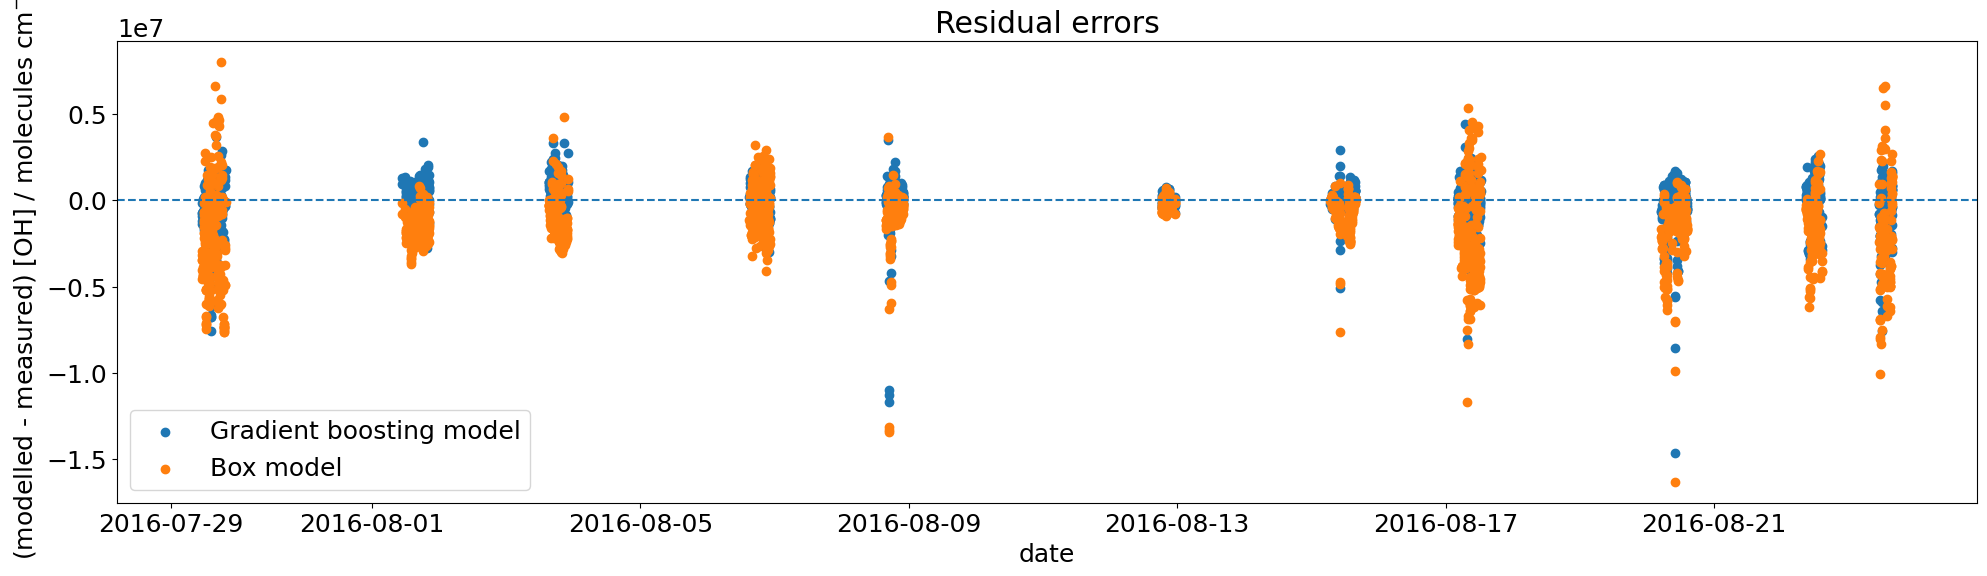

RMSE: 1382172.7741721552
RMSE with HO2: 1379549.4442700068


In [47]:
mpl.rcParams["font.size"] = 18

fig, ax1 = plt.subplots(figsize = (24, 6))
plt.scatter(df["date"][X_test.index], model.predict(X_test_normalised) - y_test, label='Gradient boosting model')
plt.scatter(df["date"][X_test.index], (df["[OH]_calc"][X_test.index] - y_test),label='Box model')

# plotting line for zero residual error
plt.axhline(y=0, linestyle = "--")

# plotting legend
plt.legend()

# plot title
plt.title("Residual errors")

plt.xlabel("date")
plt.ylabel("(modelled - measured) [OH] / molecules cm$^{-3}$")

# method call for showing the plot
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

print("RMSE with HO2:", np.sqrt(mean_squared_error(y_test, y_pred_HO2)))

In [25]:
print(len(y_test))
print(len(y_pred))

1965
1965


Text(0, 0.5, 'Feature')

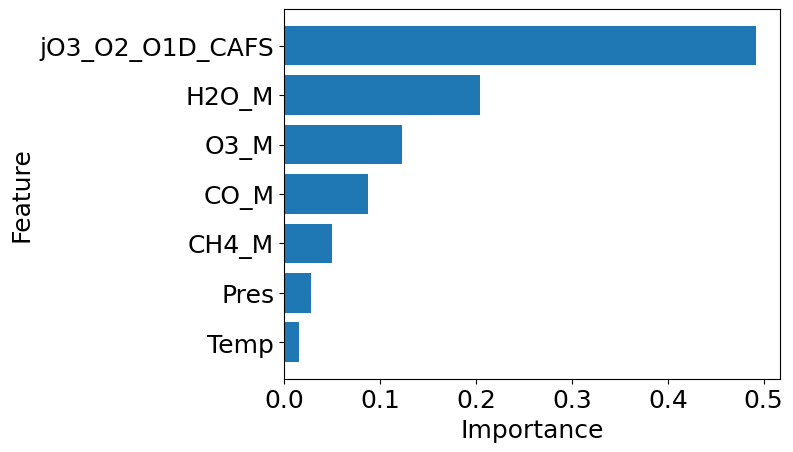

In [26]:
importances = model.feature_importances_

indices = np.argsort(importances)

fig, ax = plt.subplots()
ax.barh(range(len(importances)), importances[indices])
ax.set_yticks(range(len(importances)))
_ = ax.set_yticklabels(np.array(X_train.columns)[indices])
plt.xlabel("Importance")
plt.ylabel("Feature")